In [1]:
import clinlab.analysing as ana
import clinlab.processing as proc
import clinlab.visualising as vis

In [2]:
import pandas as pd

#### Cargar con dtypes especificos

In [3]:
pat = pd.read_csv('patients.csv')
enc = pd.read_csv('encounters.csv')
obs = pd.read_csv('observations.csv')

In [4]:
pat = proc.process_patients(pat)
enc = proc.process_encounters(enc)
obs = proc.process_observations(obs)

#### Auditar la calidad de los datos

In [5]:
ana.count_nans(obs)

,NaN percentage
Column,
obs_date,0.000000
patient,0.000000
encounter,2.620154
obs_code,0.000000
obs_desc,0.000000
units,0.000000
num_val,5.989577
non_num_val,94.974725


In [6]:
ana.duplicate_entries(pat, 'patient')  # no hay pacientes duplicados

12352 vs 12352


True

In [7]:
ana.duplicate_entries(enc, 'encounter') # no hay encuentros duplicados

321528 vs 321528


True

In [8]:
ana.duplicate_entries(obs, 'encounter') # si hay encuentros duplicados dentro del dataset observations, porque en un mismo encuentro se pueden hacer varias observaciones

40761 vs 1659750


False

In [9]:
ana.time_coherence(pat, obs)

Incoherent observations:


,patient,birthdate,deathdate,obs_date,obs_desc
0,58cac9ec-4baa-46c1-b919-0ed13572b51d,1970-06-13,2016-05-07,2016-05-14,Cause of Death [US Standard Certificate of Death]
1,c70992c9-ff13-467b-9032-1901506edeef,1959-06-17,2020-03-11,2020-03-25,Cause of Death [US Standard Certificate of Death]
2,cd7cdbef-ef08-48da-9302-19bf4b2dffa3,1940-05-03,2010-04-20,2010-04-23,Cause of Death [US Standard Certificate of Death]
3,a5c39700-6bf3-4984-af46-31344695e21b,1940-01-09,2020-03-15,2020-03-24,Cause of Death [US Standard Certificate of Death]
4,419c213d-8d35-440c-bf47-a536f95df517,1964-09-06,1999-08-29,1999-09-05,Cause of Death [US Standard Certificate of Death]
...,...,...,...,...,...
1943,91bdd91d-e86f-4873-8d70-ee18c67ecf11,1937-03-20,2015-04-03,2015-04-11,Cause of Death [US Standard Certificate of Death]
1944,a703fd9f-d0fa-49af-b61a-799b93d3606e,1936-05-09,2009-05-09,2009-05-16,Cause of Death [US Standard Certificate of Death]
1945,cc08ece6-5a10-454f-b1d8-830a4b02fd31,1957-12-09,2020-03-22,2020-03-30,Cause of Death [US Standard Certificate of Death]
1946,7475a593-3fa7-40c2-bbdf-86c68ebce67b,1918-10-20,2014-12-28,2015-01-04,Cause of Death [US Standard Certificate of Death]


#### Unir las tablas

In [10]:
full = proc.merge_full(pat, enc, obs)

#### Responder preguntas clinicas

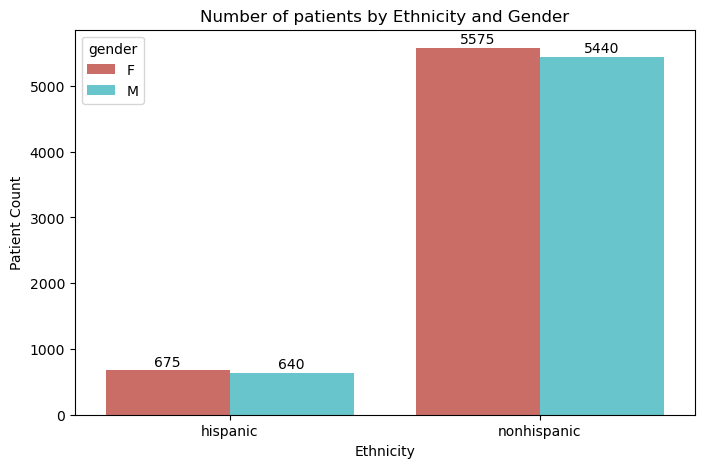

In [11]:
vis.demographic_counts(full,
                      x_col = 'ethnicity',
                      hue_col = 'gender', cont=True);

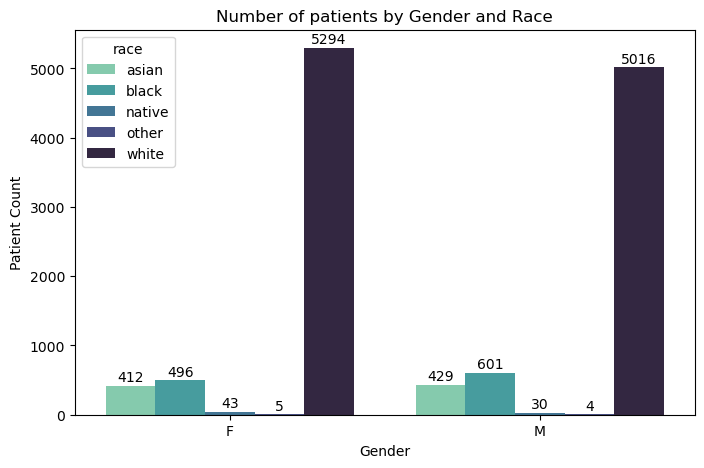

In [12]:
vis.demographic_counts(
    full,
    x_col = 'gender',
    hue_col = 'race',
    cont = True,
    palette='mako_r'
);

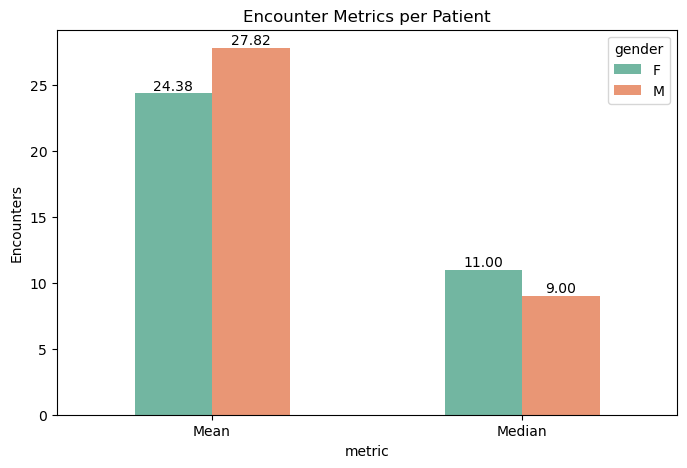

In [13]:
vis.encounter_metrics(full, hue_col='gender');

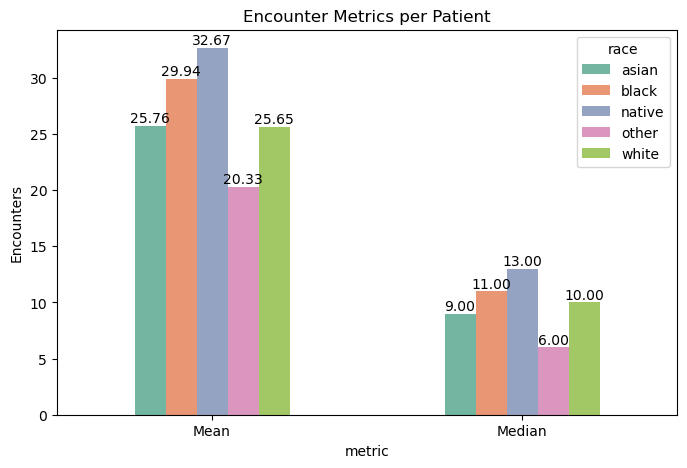

In [14]:
vis.encounter_metrics(full, hue_col='race');

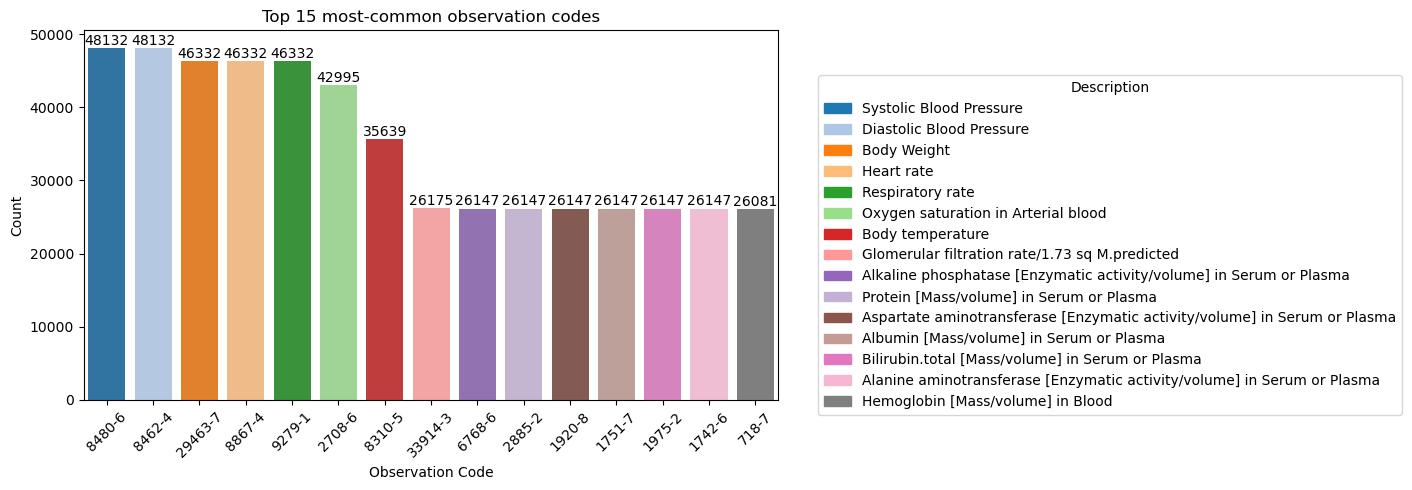

In [15]:
vis.plot_top_observation_codes(full, 15);

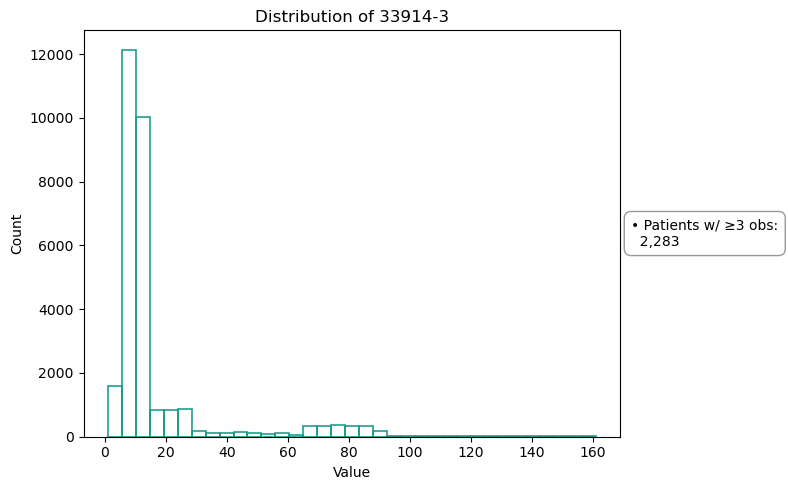

In [16]:
vis.plot_obs_distribution(
    df=full,
    obs_col='obs_code',
    obs_identifier='33914-3',
    bins=35,
);

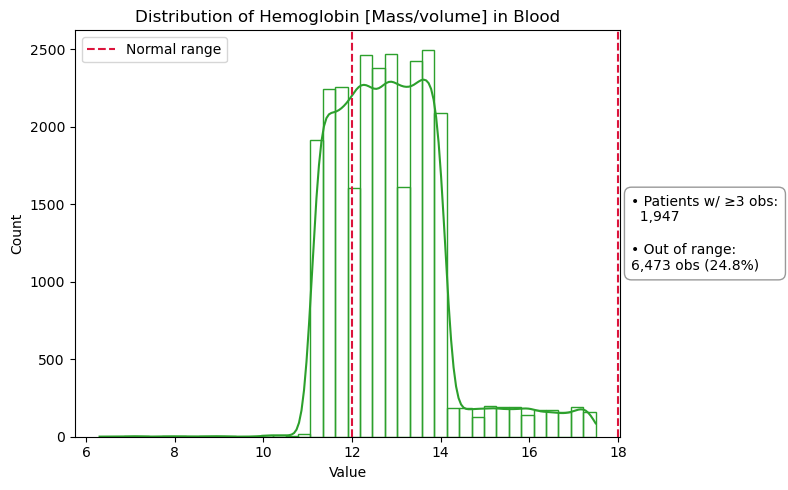

In [17]:
vis.plot_obs_distribution(
    df=full,
    obs_col='obs_desc',
    obs_identifier='Hemoglobin [Mass/volume] in Blood',
    color='tab:green',
    kde=True
);

# 8. Cobertura como diagnostico: reporte de pytest coverage

Mi paquetería cuenta con 3 módulos, en los cuales alcancé los siguientes porcentajes de cobertura con pytest:
- processing -> 40 %
- analyisng -> 90 %
- visualising -> 93 %

Alcanzando así un total de cobertura del __86%__:

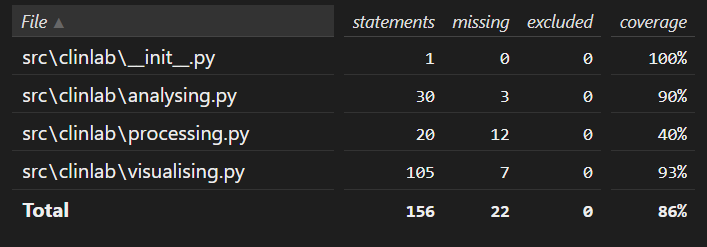

Sobre las líneas faltantes:
- En analysing, se trata de lineas dependientes de ifs especificos que no testee: e.g., en una funcion de filtrar el dataframe de acuerdo con valores limites dados por el usuario, testee pasando un limite superior pero no un limite inferior. En este caso no hay problema porque es una condicion muy general en la cual se que la funcion no truena
- En processing, el más bajo de los 3, las lineas no testeadas corresponden a las funciones utlizadas para procesar los csvs originales. Tampoco hay mayor problema porque esas funciones estan especificamente orientadas a esos archivos, asignando dtypes de acuerdo al nombre de las columnas y tal. Seria muy trivial escribirles fixtures y tests a estas funciones que no pretenden funcionar de manera general con el dataset.
- En visualising, el caso es muy similar que con analysing. Son lineas que dependen de ifs para tolerar usos generales de la funcion que no testee (e.g. pasar o no un hue) pero que se que funcionan sin mayor problema.